In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

lines_master = pd.read_csv('../master_grid_dataset.csv')
substations = pd.read_csv('substations_clean.csv')

print("Lines master shape:", lines_master.shape)
print("Substations shape:", substations.shape)
lines_master.head(2)

Lines master shape: (55, 40)
Substations shape: (44, 12)


,Line ID,Utility ID,Source Substation ID,Source Substation,Destination Substation ID,Destination Substation,Voltage (kV),Length (km),Capacity (MVA),Status,...,Capacity (MVA)_Dest,Type_Dest,Status_Dest,Utility ID_Utility,Name_Utility,Alias_Utility,Code_Utility,Type_Utility,Country_Utility,Active_Utility
0,1,2,1,Achimota Substation,2,Tema Substation,11,25.2,215.0,Active,...,48.5,Transmission,Active,2,Northern Electricity Distribution Company,NEDCo,NED,Distribution,Ghana,Y
1,2,2,1,Achimota Substation,3,Mallam Substation,11,11.0,36.4,Active,...,25.2,Transmission,Active,2,Northern Electricity Distribution Company,NEDCo,NED,Distribution,Ghana,Y


In [8]:
lines_per_utility =(
    lines_master['Alias_Utility']
    .value_counts()
    .rename_axis('Utility')
    .reset_index(name='Lines Count')
)

lines_per_utility['Share of Lines %'] = round(100 * lines_per_utility['Lines Count'] / lines_per_utility['Lines Count'].sum(), 1)
lines_per_utility



,Utility,Lines Count,Share of Lines %
0,GRIDCo,24,43.6
1,NEDCo,14,25.5
2,ECG,10,18.2
3,CEB,3,5.5
4,SONABEL,2,3.6
5,CIE,2,3.6


In [9]:
src = lines_master[['Alias_Utility', 'Source Substation ID']].rename(columns={'Source Substation ID': 'Substation ID'})
dst = lines_master[['Alias_Utility', 'Destination Substation ID']].rename(columns={'Destination Substation ID': 'Substation ID'})
utility_substation_pairs = pd.concat([src, dst]).drop_duplicates()

substations_per_utility = (
    utility_substation_pairs
    .groupby('Alias_Utility')['Substation ID']
    .nunique()
    .rename('Substation Count')
    .reset_index()
    .rename(columns={'Alias_Utility': 'Utility'})
    .sort_values('Substation Count', ascending=False)
)
substations_per_utility

,Utility,Substation Count
3,GRIDCo,26
4,NEDCo,21
2,ECG,18
0,CEB,4
1,CIE,3
5,SONABEL,3


In [10]:
utility_region = pd.crosstab(lines_master['Alias_Utility'], lines_master['Region_Source'])
utility_region['Total'] = utility_region.sum(axis=1)
utility_region = utility_region.sort_values('Total', ascending=False)
utility_region

Region_Source,Ashanti,Bono,Burkina Faso border,Central,Cote d'Ivoire border,Eastern,Greater Accra,Northern,Togo,Togo border,Upper East,Volta,Western,Total
Alias_Utility,,,,,,,,,,,,,,
GRIDCo,2,3,0,2,0,3,5,1,0,0,2,3,3,24
NEDCo,3,0,0,3,0,1,4,1,0,0,0,1,1,14
ECG,2,0,0,1,0,2,2,0,0,0,0,1,2,10
CEB,0,0,0,0,0,0,0,0,1,2,0,0,0,3
CIE,0,0,0,0,2,0,0,0,0,0,0,0,0,2
SONABEL,0,0,1,0,0,0,0,0,0,0,1,0,0,2


In [11]:

lines_master['Voltage Tier'] = pd.cut(
    lines_master['Voltage (kV)'],
    bins=[0, 33, 69, 161, 330],
    labels=['Distribution (<=33kV)', 'Sub-transmission (69kV)', 'Transmission (161kV)', 'Bulk Transmission (330kV)']
)

utility_voltage = pd.crosstab(lines_master['Alias_Utility'], lines_master['Voltage Tier'])
utility_voltage

Voltage Tier,Distribution (<=33kV),Sub-transmission (69kV),Transmission (161kV),Bulk Transmission (330kV)
Alias_Utility,,,,
CEB,0,0,0,3
CIE,0,0,0,2
ECG,6,2,1,1
GRIDCo,8,3,4,9
NEDCo,8,4,2,0
SONABEL,0,0,0,2


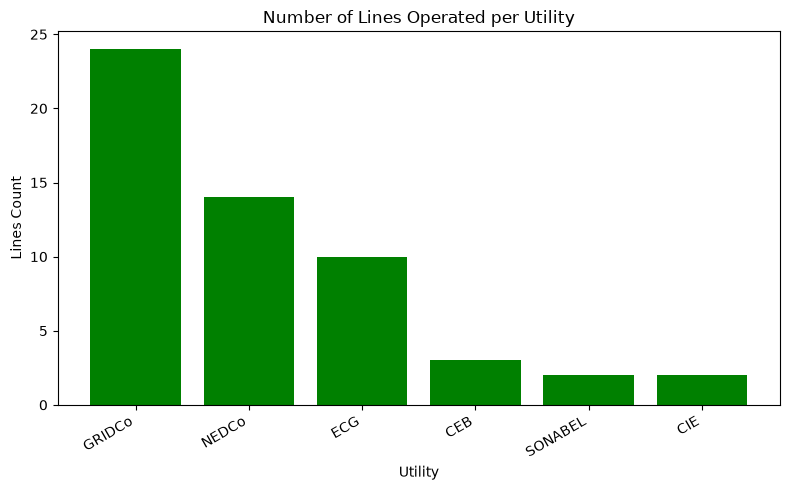

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

# Use the exact column names from your table: 'Lines Count', not 'Line Count'
ax.bar(lines_per_utility['Utility'], lines_per_utility['Lines Count'], color='green')

ax.set_title('Number of Lines Operated per Utility')
ax.set_xlabel('Utility')
ax.set_ylabel('Lines Count')


plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('task_2_3_lines_per_utility.png', dpi=150)
plt.show()

In [28]:
# Count how many lines touch each substation (as either source or destination)
source_counts = lines_master['Source Substation ID'].value_counts()
dest_counts = lines_master['Destination Substation ID'].value_counts()

# Add the two counts together, filling in 0 where a substation only appears in one list
line_counts = source_counts.add(dest_counts, fill_value=0)

# Convert this into a clean DataFrame with a proper column name
line_counts_df = line_counts.rename('Connected Lines').reset_index()

# Rename the ID column to something generic, since it now represents ALL substations
# (both source and destination), not just sources
line_counts_df = line_counts_df.rename(columns={'Source Substation ID': 'Substation ID'})

# Convert the counts from decimals (4.0) to clean whole numbers (4)
line_counts_df['Connected Lines'] = line_counts_df['Connected Lines'].astype(int)

line_counts_df.head()

,Substation ID,Connected Lines
0,1,4
1,2,4
2,3,5
3,4,4
4,5,3


In [30]:
capacity_check = substations.merge(
    line_counts_df,
    on='Substation ID',
    how='left'
)

capacity_check['Connected Lines'] = capacity_check['Connected Lines'].fillna(0).astype(int)

capacity_check = capacity_check[['Substation ID', 'Name', 'Region', 'Capacity (MVA)', 'Connected Lines']]

capacity_check.head(10)

,Substation ID,Name,Region,Capacity (MVA),Connected Lines
0,1,Achimota Substation,Greater Accra,6.4,4
1,2,Tema Substation,Greater Accra,48.5,4
2,3,Mallam Substation,Greater Accra,25.2,5
3,4,Legon Substation,Greater Accra,241.9,4
4,5,Kaneshie Substation,Greater Accra,146.0,3
5,6,Aboadze Junction Substation,Greater Accra,52.2,2
6,7,Kumasi Central Substation,Ashanti,221.4,5
7,8,Ejisu Substation,Ashanti,355.9,2
8,9,Obuasi Substation,Ashanti,47.5,2
9,10,Mampong Substation,Ashanti,189.6,2


In [35]:
# MVA per Line — how much capacity is available per connected line
# Lower value = less capacity backing each line = more strain / upgrade candidate
capacity_check['MVA per Line'] = capacity_check['Capacity (MVA)'] / capacity_check['Connected Lines']

# Sort ascending - lowest MVA per line (most strained) appears first
capacity_check_sorted = capacity_check.sort_values('MVA per Line', ascending=True)

capacity_check_sorted = capacity_check_sorted.reset_index(drop=True)

capacity_check_sorted[[
    'Substation ID', 'Name', 'Region', 'Capacity (MVA)',
    'Connected Lines', 'MVA per Line'
]].head(10)

,Substation ID,Name,Region,Capacity (MVA),Connected Lines,MVA per Line
0,1,Achimota Substation,Greater Accra,6.4,4,1.600000
1,12,Takoradi Substation,Western,14.0,4,3.500000
2,3,Mallam Substation,Greater Accra,25.2,5,5.040000
3,25,Kpong Substation,Volta,11.2,2,5.600000
4,28,Sunyani Substation,Bono,19.6,3,6.533333
5,20,Koforidua Substation,Eastern,42.4,4,10.600000
6,2,Tema Substation,Greater Accra,48.5,4,12.125000
7,31,Tamale Substation,Northern,37.4,3,12.466667
8,19,Assin Fosu Substation,Central,26.2,2,13.100000
9,16,Cape Coast Substation,Central,68.8,5,13.760000


In [ ]:
#Line-level technical-loss proxy 


# longer lines at lower voltage are expected to lose more power in transit.

# Divide length by voltage: longer lines and lower voltages both push this score up
lines_master['Loss Proxy'] = lines_master['Length (km)'] / lines_master['Voltage (kV)']

# Sort so the lines with the highest estimated loss risk appear first
loss_ranked = lines_master.sort_values('Loss Proxy', ascending=False)

# Reset the row numbers so they read cleanly (0, 1, 2...) instead of leftover sort positions
loss_ranked = loss_ranked.reset_index(drop=True)


loss_ranked[[
    'Line ID', 'Source Substation', 'Destination Substation',
    'Length (km)', 'Voltage (kV)', 'Loss Proxy'
]].head(10)

,Line ID,Source Substation,Destination Substation,Length (km),Voltage (kV),Loss Proxy
0,35,Hohoe Substation,Sogakope Substation,152.5,11,13.863636
1,26,Kasoa Substation,Assin Fosu Substation,140.9,11,12.809091
2,23,Cape Coast Substation,Kasoa Substation,118.3,11,10.754545
3,38,Tamale Substation,Yendi Substation,112.6,11,10.236364
4,28,Koforidua Substation,Nkawkaw Substation,98.0,11,8.909091
5,33,Ho Substation,Sogakope Substation,84.4,11,7.672727
6,24,Cape Coast Substation,Assin Fosu Substation,82.4,11,7.490909
7,32,Ho Substation,Kpong Substation,79.5,11,7.227273
8,34,Kpong Substation,Sogakope Substation,59.7,11,5.427273
9,27,Koforidua Substation,Akosombo Substation,48.0,11,4.363636


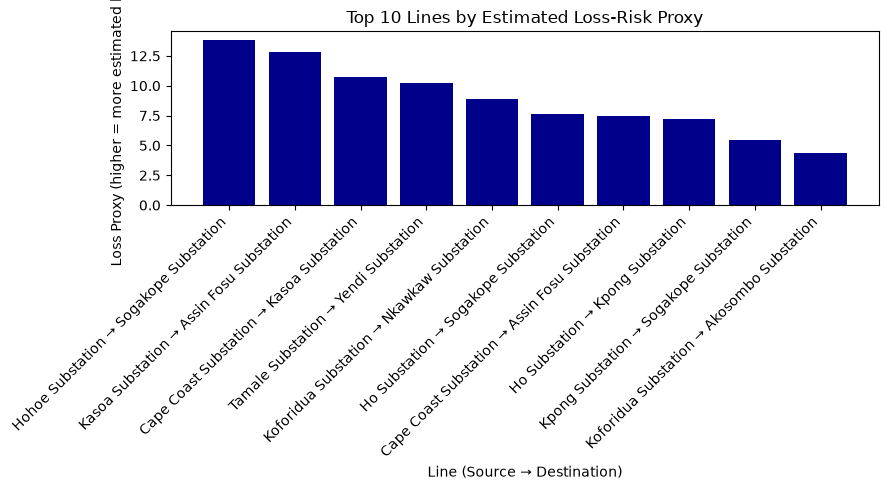

In [ ]:
#Tthe top 10 highest loss-risk lines

# Take just the top 10 rows from our already-sorted loss_ranked table
top_loss_lines = loss_ranked.head(10)

# Build a readable label for each line, combining source and destination substation names

top_loss_lines = top_loss_lines.copy()  # avoid a pandas warning when adding a new column
top_loss_lines['Line Label'] = top_loss_lines['Source Substation'] + ' → ' + top_loss_lines['Destination Substation']

fig, ax = plt.subplots(figsize=(9, 5))

# Bar chart: x-axis = line labels (source -> destination), y-axis = loss proxy score
ax.bar(top_loss_lines['Line Label'], top_loss_lines['Loss Proxy'], color='darkblue')


ax.set_title('Top 10 Lines by Estimated Loss-Risk Proxy')
ax.set_xlabel('Line (Source → Destination)')
ax.set_ylabel('Loss Proxy (higher = more estimated loss)')

# Rotate labels since "Substation A -> Substation B" text is long
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save  chart
plt.savefig('task_2_3_top_loss_risk_lines.png', dpi=150)
plt.show()

In [ ]:
#  Step 4: Growth Opportunities - identify underserved regions

#  use substation count and total capacity per region as a proxy for how "built out" each region's grid infrastructure is.
# Regions with very few substations and low total capacity may represent growth opportunities.

# Count substations per region
substations_per_region = substations.groupby('Region').size().rename('Substation Count')

# Sum total capacity (MVA) per region
capacity_per_region = substations.groupby('Region')['Capacity (MVA)'].sum().rename('Total Capacity (MVA)')

# Combine both into one table (axis=1 = combine side by side as columns)
region_infrastructure = pd.concat([substations_per_region, capacity_per_region], axis=1).reset_index()

# Sort ascending - regions with the FEWEST substations appear first (potential growth targets)
region_infrastructure_sorted = region_infrastructure.sort_values('Substation Count', ascending=True)

""" Restrict the analysis to Ghana's official administrative regions Crosss-border hubs (e.g., Benin, Togo, and Guinea) are internationalinterconnection points rather than Ghanaian administrative regions.
 Excluding them prevents these single-point connections from distorting the regional growth-opportunity ranking and keeps the investment analysis focused on Ghana's actual regions."""

ghana_regions_list = [
    'Greater Accra', 'Ashanti', 'Western', 'Central', 'Eastern',
    'Volta', 'Bono', 'Northern', 'Upper East', 'Upper West'
]

region_infrastructure_ghana = region_infrastructure_sorted[
    region_infrastructure_sorted['Region'].isin(ghana_regions_list)
]

# Reset row numbers so they read cleanly (0, 1, 2...) instead of leftover sort positions
region_infrastructure_ghana = region_infrastructure_ghana.reset_index(drop=True)

region_infrastructure_ghana

,Region,Substation Count,Total Capacity (MVA)
0,Upper West,1,27.1
1,Upper East,2,520.7
2,Bono,3,252.6
3,Northern,3,155.6
4,Eastern,4,828.5
5,Central,4,316.2
6,Western,4,323.0
7,Volta,4,470.3
8,Ashanti,5,1099.6
9,Greater Accra,6,520.2


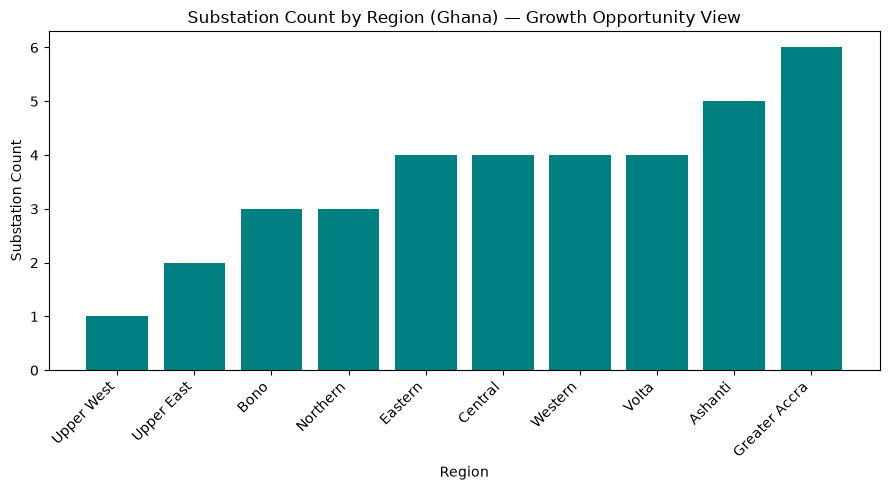

In [ ]:
#  Visualize substation count by region (Ghana only) 

fig, ax = plt.subplots(figsize=(9, 5))

# Bar chart: x-axis = region names, y-axis = substation count
ax.bar(region_infrastructure_ghana['Region'], region_infrastructure_ghana['Substation Count'], color='teal')

ax.set_title('Substation Count by Region (Ghana) — Growth Opportunity View')
ax.set_xlabel('Region')
ax.set_ylabel('Substation Count')




plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the chart
plt.savefig('task_2_3_substations_by_region_growth.png', dpi=150)
plt.show()

In [ ]:
"""   Asset Age Profile 
Older infrastructure generally carries higher fault-risk. We use Commissioning Year
to estimate each substation's age and look at how age is distributed across the network."""

# Calculate each substation's age in years, based on the current year
current_year = 2026
substations['Age (Years)'] = current_year - substations['Commissioning Year']

# Basic summary statistics: min, max, average age across all substations
print(substations['Age (Years)'].describe())

# Show the 10 oldest substations - the highest fault-risk candidates
oldest_substations = substations.sort_values('Age (Years)', ascending=False)
oldest_substations = oldest_substations.reset_index(drop=True)  # clean row numbers

oldest_substations[['Substation ID', 'Name', 'Region', 'Commissioning Year', 'Age (Years)']].head(10)

count    44.000000
mean     29.704545
std      16.112366
min       4.000000
25%      16.750000
50%      26.500000
75%      43.750000
max      59.000000
Name: Age (Years), dtype: float64


,Substation ID,Name,Region,Commissioning Year,Age (Years)
0,13,Aboadze Substation,Western,1967,59
1,31,Tamale Substation,Northern,1969,57
2,5,Kaneshie Substation,Greater Accra,1970,56
3,17,Winneba Substation,Central,1970,56
4,35,Bawku Substation,Upper East,1971,55
5,15,Axim Substation,Western,1974,52
6,23,Suhum Substation,Eastern,1975,51
7,36,Wa Substation,Upper West,1977,49
8,32,Yendi Substation,Northern,1978,48
9,3,Mallam Substation,Greater Accra,1979,47


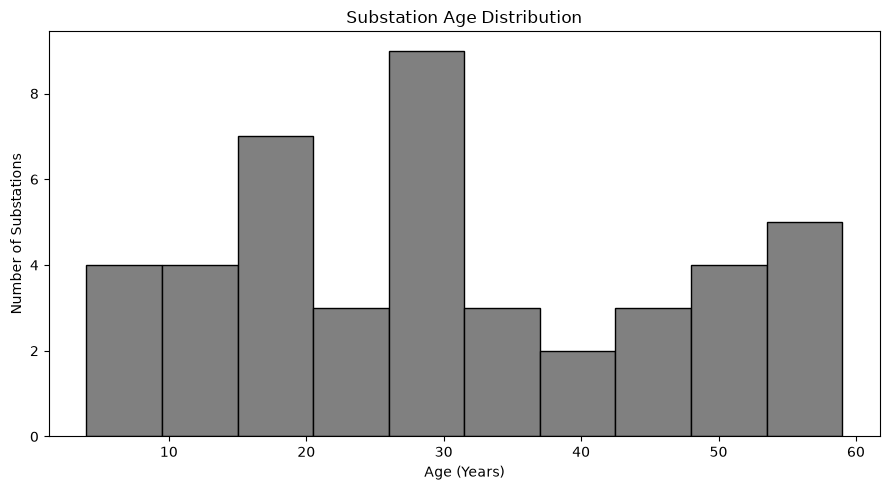

In [ ]:
# Visualizing the age distribution across all substations 

fig, ax = plt.subplots(figsize=(9, 5))

# A histogram groups ages into "bins" (ranges) and counts how many substations fall
# into each range - this shows the overall shape of the age distribution at a glance
ax.hist(substations['Age (Years)'], bins=10, color='grey', edgecolor='black')

ax.set_title('Substation Age Distribution')
ax.set_xlabel('Age (Years)')
ax.set_ylabel('Number of Substations')

plt.tight_layout()

# Saving the chart
plt.savefig('task_2_3_substation_age_distribution.png', dpi=150)
plt.show()

In [ ]:
# Comparing network structure: older vs newer substations 
# Split substations into two groups using the median age as the cutoff, so each group
# has roughly equal size, then compare their typical capacity and connectivity.

median_age = substations['Age (Years)'].median()

# Labelling each substation as 'Older' or 'Newer' relative to the median
substations['Age Group'] = substations['Age (Years)'].apply(
    lambda age: 'Older' if age >= median_age else 'Newer'
)

substations_with_lines = substations.merge(line_counts_df, on='Substation ID', how='left')
substations_with_lines['Connected Lines'] = substations_with_lines['Connected Lines'].fillna(0)

# Compare average capacity and average connections between the two age groups
age_group_comparison = substations_with_lines.groupby('Age Group').agg(
    Avg_Capacity_MVA=('Capacity (MVA)', 'mean'),
    Avg_Connected_Lines=('Connected Lines', 'mean'),
    Substation_Count=('Substation ID', 'count')
).round(1)

age_group_comparison

,Avg_Capacity_MVA,Avg_Connected_Lines,Substation_Count
Age Group,,,
Newer,147.8,2.4,22
Older,167.9,2.6,22


In [ ]:
#Step 6a: Proportion of lines "Under Maintenance" by region and by utility 

# A high maintenance rate can signal reliability risk - either aging infrastructure
# needing frequent repair, or heavy maintenance activity currently underway.



maintenance_by_region = pd.crosstab(
    lines_master['Region_Source'],
    lines_master['Status'],
    normalize='index'
) * 100

# Round off values and sort by maintenance percentage, highest first
maintenance_by_region = maintenance_by_region.round(1)
if 'Under Maintenance' in maintenance_by_region.columns:
    maintenance_by_region = maintenance_by_region.sort_values('Under Maintenance', ascending=False)

maintenance_by_region

Status,Active,Under Maintenance
Region_Source,,
Central,83.3,16.7
Greater Accra,90.9,9.1
Ashanti,100.0,0.0
Burkina Faso border,100.0,0.0
Bono,100.0,0.0
Cote d'Ivoire border,100.0,0.0
Eastern,100.0,0.0
Northern,100.0,0.0
Togo,100.0,0.0


In [ ]:

#  The regional breakdown grouped by which utility operates the line

maintenance_by_utility = pd.crosstab(
    lines_master['Alias_Utility'],
    lines_master['Status'],
    normalize='index'
) * 100

maintenance_by_utility = maintenance_by_utility.round(1)
if 'Under Maintenance' in maintenance_by_utility.columns:
    maintenance_by_utility = maintenance_by_utility.sort_values('Under Maintenance', ascending=False)

maintenance_by_utility

Status,Active,Under Maintenance
Alias_Utility,,
ECG,90.0,10.0
GRIDCo,95.8,4.2
CIE,100.0,0.0
CEB,100.0,0.0
NEDCo,100.0,0.0
SONABEL,100.0,0.0


In [ ]:
# Step 6c: Capacity concentration risk 
# If a small number of substations hold a large share of total network capacity,
# the network is more vulnerable - losing just one of them has an outsized impact.
# We check this by ranking substations by capacity and seeing how much of the total
# is held by the top 5 and top 10.

# Sort substations by capacity, highest first
capacity_sorted = substations.sort_values('Capacity (MVA)', ascending=False).reset_index(drop=True)

# Total capacity across the whole network
total_capacity = capacity_sorted['Capacity (MVA)'].sum()

# Sum of capacity held by just the top 5 and top 10 substations
top5_capacity = capacity_sorted.head(5)['Capacity (MVA)'].sum()
top10_capacity = capacity_sorted.head(10)['Capacity (MVA)'].sum()

# Express each as a percentage of the network's total capacity
top5_share = round(100 * top5_capacity / total_capacity, 1)
top10_share = round(100 * top10_capacity / total_capacity, 1)

print(f"Total network capacity: {total_capacity:.1f} MVA")
print(f"Top 5 substations hold: {top5_capacity:.1f} MVA ({top5_share}%)")
print(f"Top 10 substations hold: {top10_capacity:.1f} MVA ({top10_share}%)")

Total network capacity: 6946.1 MVA
Top 5 substations hold: 2128.0 MVA (30.6%)
Top 10 substations hold: 3719.1 MVA (53.5%)


In [59]:

# A quick-reference summary of the headline findings from this notebook.



print("=" * 60)
print("GRID BUSINESS INTELLIGENCE - KEY METRICS SUMMARY")
print("=" * 60)

# Dominant utility (from Step 2)
top_utility = lines_per_utility.iloc[0]
print(f"\nDominant utility: {top_utility['Utility']} "
      f"({top_utility['Lines Count']} lines, {top_utility['Share of Lines %']}% of network)")

# Most strained substation (from Step 3)
most_strained = capacity_check_sorted.iloc[0]
print(f"\nMost strained substation: {most_strained['Name']} "
      f"({most_strained['MVA per Line']:.1f} MVA per connected line)")

# Highest loss-risk line (from Step 3)
highest_loss_line = loss_ranked.iloc[0]
print(f"\nHighest loss-risk line: {highest_loss_line['Source Substation']} -> "
      f"{highest_loss_line['Destination Substation']} "
      f"(Loss Proxy: {highest_loss_line['Loss Proxy']:.2f})")

# Most underserved region (from Step 4)
most_underserved = region_infrastructure_ghana.iloc[0]
print(f"\nMost underserved region: {most_underserved['Region']} "
      f"({most_underserved['Substation Count']} substations, "
      f"{most_underserved['Total Capacity (MVA)']} MVA total)")

# Oldest substation (from Step 5)
oldest = oldest_substations.iloc[0]
print(f"\nOldest substation: {oldest['Name']} ({oldest['Age (Years)']} years old)")

# Capacity concentration (from Step 6)
print(f"\nCapacity concentration risk: top 10 substations hold {top10_share}% of total network capacity")

print("\n" + "=" * 60)

GRID BUSINESS INTELLIGENCE - KEY METRICS SUMMARY

Dominant utility: GRIDCo (24 lines, 43.6% of network)

Most strained substation: Achimota Substation (1.6 MVA per connected line)

Highest loss-risk line: Hohoe Substation -> Sogakope Substation (Loss Proxy: 13.86)

Most underserved region: Upper West (1 substations, 27.1 MVA total)

Oldest substation: Aboadze Substation (59 years old)

Capacity concentration risk: top 10 substations hold 53.5% of total network capacity



Strategic Recommendations

The findings from the business intelligence and reliability analysis highlight several areas where targeted intervention could strengthen the resilience, efficiency, and future capacity of the National Electricity Grid.
The following recommendations are therefore proposed:

1. Prioritize Achimota Substation for Capacity Expansion

Achimota Substation is a key area of concern because it serves four connected lines while having only 6.4 MVA of rated capacity, equivalent to approximately 1.6 MVA per line. 
This represents the lowest capacity-to-connection ratio identified across the network. 
Its relatively limited capacity compared with the number of connected lines increases the potential for congestion and overloading. 
Capacity expansion at Achimota should therefore be treated as a priority investment to improve reliability and accommodate future demand.

2. Investigate the Hohoe–Sogakope Transmission Line for Loss Reduction

The Hohoe–Sogakope transmission line records the highest loss-risk proxy score in the analysis, at 13.86. 
This is largely associated with the combination of its relatively long transmission distance and lower operating voltage.
A detailed technical assessment should be undertaken to determine whether upgrading the line to a higher voltage level,
improving its configuration, or considering an alternative routing strategy could reduce transmission losses and improve overall efficiency.

3. Prioritize Grid Expansion in the Upper West Region

The Upper West Region appears to be the most underserved region represented in the dataset, with only one substation and a combined capacity of 27.1 MVA.
The substantial gap between its existing infrastructure and the capacity available in other regions suggests significant room for network development. 
Future investment planning should therefore give greater consideration to new substations and transmission infrastructure in the region, particularly where projected demand and geographic coverage justify expansion.

4. Adopt a Phased Approach to Replacing Aging Infrastructure

Asset age is another important consideration for long-term grid reliability.
Aboadze Substation is the oldest asset identified, at 59 years, while five additional substations fall within the 50–58 year age range. 
Rather than waiting for these assets to experience major failures, a phased replacement and refurbishment programme should be developed.
Prioritizing assets according to age, condition, criticality, and failure consequences would help manage maintenance costs while reducing the risk of unexpected outages.

5. Reduce the Risk Created by Capacity Concentration

The analysis shows that the ten largest substations, representing only about 23% of all substations, account for approximately 53.5% of the network's total capacity. 
This concentration creates a significant reliability concern because failures at one or two major substations could have disproportionate effects on electricity supply. 
The grid should therefore strengthen redundancy and contingency arrangements around these high-capacity assets.
N-1 contingency planning, alternative supply pathways, and strategically distributed capacity could help limit the impact of individual asset failures and improve overall system resilience.
